<a href="https://colab.research.google.com/github/ShashankSatishkumar/NNDLQHOproject/blob/main/anharmonicoscillator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 0 | Loss: 249.13867 | E0: 0.5050 | E1: 1.5050
Epoch 500 | Loss: 0.69959 | E0: 0.5797 | E1: 0.8134
Epoch 1000 | Loss: 0.19131 | E0: 0.5941 | E1: 1.2868
Epoch 1500 | Loss: 0.27698 | E0: 0.5995 | E1: 1.8912
Epoch 2000 | Loss: 0.01061 | E0: 0.5947 | E1: 1.7758
Epoch 2500 | Loss: 0.00644 | E0: 0.5870 | E1: 1.7738


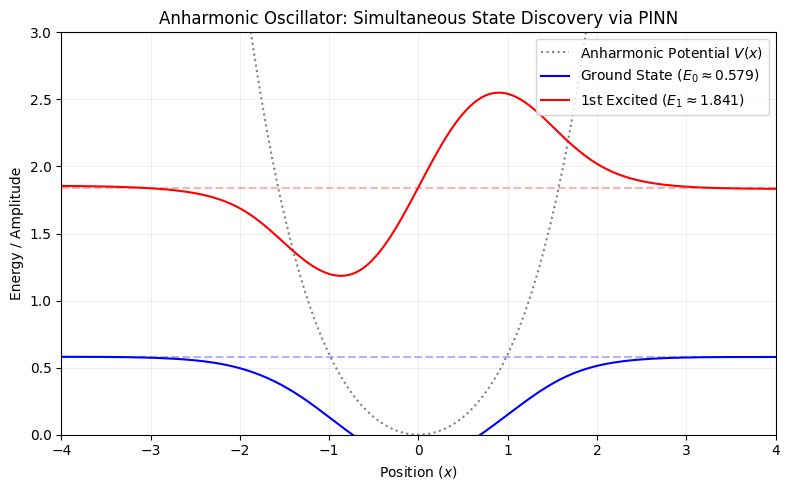

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


class AnharmonicPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 2)
        )

        self.E0 = nn.Parameter(torch.tensor([0.5]))
        self.E1 = nn.Parameter(torch.tensor([1.5]))

    def forward(self, x):
        outputs = self.net(x)
        psi_0 = outputs[:, 0:1]
        psi_1 = outputs[:, 1:2]
        return psi_0, psi_1

def get_second_derivative(psi, x):

    dpsi_dx = torch.autograd.grad(psi, x,
                                  grad_outputs=torch.ones_like(psi),
                                  create_graph=True)[0]

    d2psi_dx2 = torch.autograd.grad(dpsi_dx, x,
                                    grad_outputs=torch.ones_like(dpsi_dx),
                                    create_graph=True)[0]
    return d2psi_dx2

model = AnharmonicPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)


x_min, x_max, steps = -5.0, 5.0, 400
x = torch.linspace(x_min, x_max, steps, requires_grad=True).view(-1, 1)
dx = (x_max - x_min) / steps


lambda_perturbation = 0.1

V = (0.5 * x**2 + lambda_perturbation * x**4).detach()

epochs = 3000
for epoch in range(epochs):
    optimizer.zero_grad()

    psi_0, psi_1 = model(x)

    d2psi0_dx2 = get_second_derivative(psi_0, x)
    d2psi1_dx2 = get_second_derivative(psi_1, x)

    res_0 = -0.5 * d2psi0_dx2 + V * psi_0 - model.E0 * psi_0
    res_1 = -0.5 * d2psi1_dx2 + V * psi_1 - model.E1 * psi_1
    loss_pde = torch.mean(res_0**2) + torch.mean(res_1**2)

    norm_0 = torch.sum(psi_0**2) * dx
    norm_1 = torch.sum(psi_1**2) * dx
    loss_norm = (norm_0 - 1.0)**2 + (norm_1 - 1.0)**2

    overlap = torch.sum(psi_0 * psi_1) * dx
    loss_ortho = overlap**2

    loss_boundary = psi_0[0,0]**2 + psi_0[-1,0]**2 + psi_1[0,0]**2 + psi_1[-1,0]**2

    loss = loss_pde + loss_norm + loss_ortho + loss_boundary
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.5f} | E0: {model.E0.item():.4f} | E1: {model.E1.item():.4f}")

psi_0_num = psi_0.detach().numpy()
psi_1_num = psi_1.detach().numpy()
x_num = x.detach().numpy()
V_num = V.detach().numpy()

plt.figure(figsize=(8, 5))
plt.plot(x_num, V_num, color='gray', linestyle='dotted', label='Anharmonic Potential $V(x)$')

E0_val = model.E0.item()
E1_val = model.E1.item()

plt.plot(x_num, psi_0_num + E0_val, label=f'Ground State ($E_0 \\approx {E0_val:.3f}$)', color='blue')
plt.plot(x_num, psi_1_num + E1_val, label=f'1st Excited ($E_1 \\approx {E1_val:.3f}$)', color='red')

plt.axhline(E0_val, color='blue', linestyle='--', alpha=0.3)
plt.axhline(E1_val, color='red', linestyle='--', alpha=0.3)

plt.ylim(0, 3)
plt.xlim(-4, 4)
plt.title("Anharmonic Oscillator: Simultaneous State Discovery via PINN")
plt.xlabel("Position ($x$)")
plt.ylabel("Energy / Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("anharmonic_pinn_results.jpg", format='jpg', dpi=300)
plt.show()